# Model Baseline Comparison

## Final Scores

| Model | Train AP | Test AP | Gap (Train - Test) | Status |
| --- | --- | --- | --- | --- |
| **Base LogReg** | 0.086710 | 0.104564 | -0.017854 | Underfitting |
| **Base GB (Default)** | 0.202190 | 0.098519 | +0.103671 | **Overfitting** |
| **Tuned GB (Optimized)** | **0.110313** | **0.115013** | **-0.004700** | **Winner (Stable)** |

---

## Performance Lift (Tuned GB vs. Others)

* **vs. Default GB (Overfitting Slayer):**
* Train AP: **-45.44%** (dropped train memorization)
* Test AP: **+16.74%** (gained real-world predictive power)


* **vs. Base LogReg (Complexity Winner):**
* Train AP: **+27.22%**
* Test AP: **+9.99%**



---

## Bottom Line

**Tuned GB is the clear winner.** The default Gradient Boosting model severely overfits (massive train score, terrible test score). Tuning successfully penalized this complexity, yielding the highest test score with a near-perfect generalization gap.

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
from pathlib import Path
import sys

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

In [31]:
READ_CSV="../../data/interim/data_travel_insurance_interim.csv"
SAVE_RESULT = "results/voting_stacking_optimization.csv"
RANDOM_STATE=42


TARGET_TRANSFORM_COLS = ["Destination"]
LOG_TRANSFORM_COLS= ["Duration", "Net Sales"]

In [32]:
from src.utils import benchmark_models

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectFdr, SelectFromModel, f_classif
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

from feature_engine.outliers import Winsorizer

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [33]:
df = pd.read_csv(READ_CSV)
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim,Is Refund,Suspected Fraud,Commission Rate
0,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,216.0,54.0,57,0,No,No,0.25
1,EPX,Travel Agency,Online,Cancellation Plan,4,MALAYSIA,10.0,0.0,33,0,No,No,0.00
2,JZI,Airlines,Online,Basic Plan,19,INDIA,22.0,7.7,26,0,No,No,0.35
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,20,UNITED STATES,112.0,0.0,59,0,No,No,0.00
4,C2B,Airlines,Online,Bronze Plan,8,SINGAPORE,16.0,4.0,28,0,No,No,0.25


In [34]:
x = df.drop(columns=["Claim"])
y = df["Claim"]


In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [36]:
NUMERIC_COLS = [features for features in x_train.columns if x_train[features].dtypes != "O"]
CATEGORICAL_COLS = [features for features in x_train.columns if x_train[features].dtypes == "O"]


In [37]:
def tuned_pipeline():
    numeric_pipeline = Pipeline([
    ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
    ("RobustScaler", RobustScaler()),
    ])

    numeric_log_pipeline = Pipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("RobustScaler", RobustScaler()),
    ])

    categorical_ohe_pipeline = Pipeline([
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
    ])

    categorical_target_pipeline = Pipeline([
        ("TargetEncoder", TargetEncoder())
    ])
    
    preprocessor = ColumnTransformer(
        [
            ("numeric_pipeline", numeric_pipeline, [c for c in NUMERIC_COLS if c not in LOG_TRANSFORM_COLS]),
            ("numeric_log_pipeline", numeric_log_pipeline, LOG_TRANSFORM_COLS),
            ("categorical_ohe_pipeline", categorical_ohe_pipeline, [c for c in CATEGORICAL_COLS if c not in TARGET_TRANSFORM_COLS]),
            ("categorical_target_pipeline", categorical_target_pipeline, TARGET_TRANSFORM_COLS),
        ],
        remainder="drop"
    )   
    
    gb_pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("feature_selection", SelectFdr(score_func=f_classif, alpha=0.005)),
        ("resampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
    
    gb_best_params = {
        'classifier__learning_rate': 0.020585312110064476,
        'classifier__max_depth': 4,
        'classifier__max_features': 'log2',
        'classifier__min_samples_leaf': 26,
        'classifier__min_samples_split': 42,
        'classifier__n_estimators': 177,
        'classifier__subsample': 0.8227412591061039
    }
    gb_pipeline.set_params(**gb_best_params)
    
    return gb_pipeline


In [38]:
def base_pipeline():
    numeric_pipeline = Pipeline([
        ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
        ("RobustScaler", RobustScaler()),
    ])

    categorical_ohe_pipeline = Pipeline([
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
    ])

    preprocessor = ColumnTransformer(
        [
            ("numeric_pipeline", numeric_pipeline, NUMERIC_COLS),
            ("categorical_ohe_pipeline", categorical_ohe_pipeline, CATEGORICAL_COLS),
        ],
        remainder="drop"
    )
    
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(random_state=42))
        ]
    )

In [39]:
gb_tuned_pipeline = tuned_pipeline()
logreg_base_pipeline = base_pipeline()
gb_base_pipeline = base_pipeline()
gb_base_pipeline.set_params(classifier=GradientBoostingClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('categorical_ohe_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
pipelines = {
    "Base LogReg": logreg_base_pipeline,
    "Base GB (Default)": gb_base_pipeline,
    "Tuned GB (Optimized)": gb_tuned_pipeline
}

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(x_train, y_train)
    
    train_prob = pipeline.predict_proba(x_train)[:, 1]
    test_prob = pipeline.predict_proba(x_test)[:, 1]
    
    train_ap = average_precision_score(y_train, train_prob)
    test_ap = average_precision_score(y_test, test_prob)
    
    results.append({
        "Model": name,
        "Train AP": train_ap,
        "Test AP": test_ap
    })

df_scores = pd.DataFrame(results)
df_scores.sort_values("Test AP", ascending=False)

,Model,Train AP,Test AP
2,Tuned GB (Optimized),0.110313,0.115013
0,Base LogReg,0.086710,0.104564
1,Base GB (Default),0.202190,0.098519


In [55]:
gb_tuned_pipeline

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('numeric_log_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:

lr_train, lr_test = df_scores.loc[0, ["Train AP", "Test AP"]]
base_gb_train, base_gb_test = df_scores.loc[1, ["Train AP", "Test AP"]]
tuned_train, tuned_test = df_scores.loc[2, ["Train AP", "Test AP"]]

train_lift_abs_gb = tuned_train - base_gb_train
train_lift_pct_gb = (train_lift_abs_gb / base_gb_train) * 100

test_lift_abs_gb = tuned_test - base_gb_test
test_lift_pct_gb = (test_lift_abs_gb / base_gb_test) * 100

train_lift_abs_lr = tuned_train - lr_train
train_lift_pct_lr = (train_lift_abs_lr / lr_train) * 100

test_lift_abs_lr = tuned_test - lr_test
test_lift_pct_lr = (test_lift_abs_lr / lr_test) * 100

print("\n" + "="*50)
print("             FINAL MODEL COMPARISON TABLE")
print("="*50)
print(df_scores.to_markdown(index=False))
print("="*50)

print("\n" + "="*50)
print("             PERFORMANCE LIFT ANALYSIS")
print("="*50)
print(f"1. TUNED GB vs. BASE GB (DEFAULT):")
print(f"   - Train AP: {tuned_train:.6f} vs {base_gb_train:.6f} | Lift: {train_lift_abs_gb:+.6f} ({train_lift_pct_gb:+.2f}%)")
print(f"   - Test AP : {tuned_test:.6f} vs {base_gb_test:.6f} | Lift: {test_lift_abs_gb:+.6f} ({test_lift_pct_gb:+.2f}%)")
print("\n   Insight: If default GB has massive Train AP but low Test AP compared to Tuned,")
print("   your hyperparameter tuning successfully solved overfitting!")

print(f"\n2. TUNED GB vs. BASE LOGREG:")
print(f"   - Train AP: {tuned_train:.6f} vs {lr_train:.6f} | Lift: {train_lift_abs_lr:+.6f} ({train_lift_pct_lr:+.2f}%)")
print(f"   - Test AP : {tuned_test:.6f} vs {lr_test:.6f} | Lift: {test_lift_abs_lr:+.6f} ({test_lift_pct_lr:+.2f}%)")
print("="*50)


             FINAL MODEL COMPARISON TABLE
| Model                |   Train AP |   Test AP |
|:---------------------|-----------:|----------:|
| Base LogReg          |  0.0867104 |  0.104564 |
| Base GB (Default)    |  0.20219   |  0.098519 |
| Tuned GB (Optimized) |  0.110313  |  0.115013 |

             PERFORMANCE LIFT ANALYSIS
1. TUNED GB vs. BASE GB (DEFAULT):
   - Train AP: 0.110313 vs 0.202190 | Lift: -0.091877 (-45.44%)
   - Test AP : 0.115013 vs 0.098519 | Lift: +0.016494 (+16.74%)

   Insight: If default GB has massive Train AP but low Test AP compared to Tuned,
   your hyperparameter tuning successfully curbed overfitting!

2. TUNED GB vs. BASE LOGREG:
   - Train AP: 0.110313 vs 0.086710 | Lift: +0.023603 (+27.22%)
   - Test AP : 0.115013 vs 0.104564 | Lift: +0.010449 (+9.99%)


In [79]:
f = gb_tuned_pipeline[:2].get_feature_names_out()
fi = gb_tuned_pipeline.named_steps["classifier"].feature_importances_

df = pd.DataFrame({
    "Features": f,
    "Importances": fi
})

df.sort_values("Importances", ascending=False)

,Features,Importances
5,categorical_ohe_pipeline__Agency_C2B,0.217572
22,categorical_target_pipeline__Destination,0.164352
2,numeric_pipeline__Commission Rate,0.146744
4,numeric_log_pipeline__Net Sales,0.101593
0,numeric_pipeline__Commission,0.089399
3,numeric_log_pipeline__Duration,0.060896
10,categorical_ohe_pipeline__Agency Type_Travel A...,0.047538
17,categorical_ohe_pipeline__Product Name_Cancell...,0.036691
1,numeric_pipeline__Age,0.031740
7,categorical_ohe_pipeline__Agency_EPX,0.026899


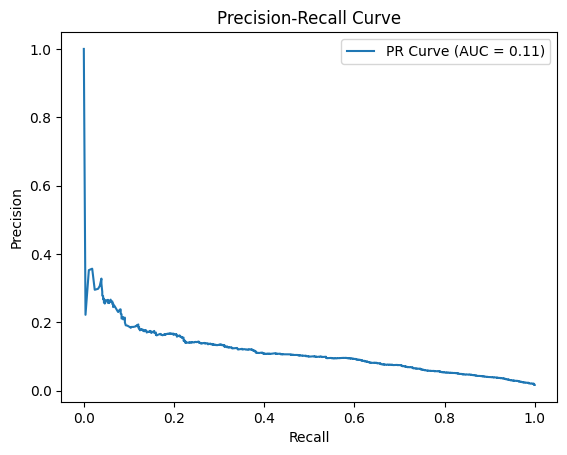

In [ ]:
    # Kalo model prediksi claim, namun ternyata tidak klaim -> implikasinya pengelolaan resiko sudah dilakukan namun sia sia
    # kalo model prediksi tidak claim, namun ternyata tidak klaim -> implikasinya pengelolaan resiko tidak di lakukan namun ternayata ada klaim yang besar dilakukan
# recall case
gb_tuned_pipeline = tuned_pipeline()
gb_tuned_pipeline.fit(x_train, y_train)
train_prob = gb_tuned_pipeline.predict_proba(x_train)[:, 1]
test_prob = gb_tuned_pipeline.predict_proba(x_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_train, train_prob)
auc_pr = average_precision_score(y_train, train_prob)

# Plotting the curve
plt.plot(recall, precision, label=f'PR Curve (AUC = {auc_pr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
